# Калкулатор за изчислявяне на бал за прием в 8 клас след НВО 

## Селекция и сортировки по различни критерии

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import statistics as st
#plt.style.use('dark_background')
import polars as pl 
pl.Config(
    tbl_rows=-1,          # Показва абсолютно всички редове (-1 премахва лимита)
    tbl_cols=-1,          # Показва абсолютно всички колони (-1 премахва лимита)
    fmt_str_lengths=1000, # Максимален брой символи в текстова колона преди съкращаване
    tbl_width_chars=500   # Обща ширина на таблицата, за да не се пренасят колоните долу
)
pd.set_option('display.max_rows' , None)
#print(plt.style.available) 

#### Данни за проекта - ( източник МОН ) 

In [2]:
my_data = pd.read_csv('scores_csv.csv') 

## Общя информация и Статистика:

#### Рангове 

In [3]:
ranking = {
           'score':[ 'до 29,75 точки', 'от 30 до 51.50 точки', ' от 51.75 до 62.25 точки',
                     'от 62.50 до 83,75 точки', 'от 84 до 100 точки'],
           'evaluate':['Слаб', 'Среден', 'Добър','Много добър', 'Отличен'] 
} 

In [94]:
info_ranking = pd.DataFrame(ranking).rename(columns={'score':'Резултати', 'evaluate':'Оценки'}).reset_index(drop='index') 

info_ranking.set_index('Оценки').T           

Оценки,Слаб,Среден,Добър,Много добър,Отличен
Резултати,"до 29,75 точки",от 30 до 51.50 точки,от 51.75 до 62.25 точки,"от 62.50 до 83,75 точки",от 84 до 100 точки


### Статистическа информация за предходни години 

In [5]:
data = {
    'Year': [2021, 2022, 2023, 2024, 2025],
    'BEL_BG': [53.86, 53.63, 55.04, 54.61, 55.91],
    'BEL_SF': [65.21, 65.41, 66.83, 65.16, 68.3],
    'MAT_BG': [37.94, 35.32, 35.29, 42.94, 42.47],
    'MAT_SF': [51.5, 47.33, 48.06, 54.73, 54.87]
}

info = pd.DataFrame(data)
info.rename(columns={'Year':'Години', 'BEL_BG':'НВО-БЕЛ:Бг','BEL_SF':'НВО-БЕЛ:Сф','MAT_BG':'НВО-МАТ:Бг','MAT_SF':'НВО-МАТ:Сф'}).set_index('Години') 	

,НВО-БЕЛ:Бг,НВО-БЕЛ:Сф,НВО-МАТ:Бг,НВО-МАТ:Сф
Години,,,,
2021,53.86,65.21,37.94,51.50
2022,53.63,65.41,35.32,47.33
2023,55.04,66.83,35.29,48.06
2024,54.61,65.16,42.94,54.73
2025,55.91,68.30,42.47,54.87


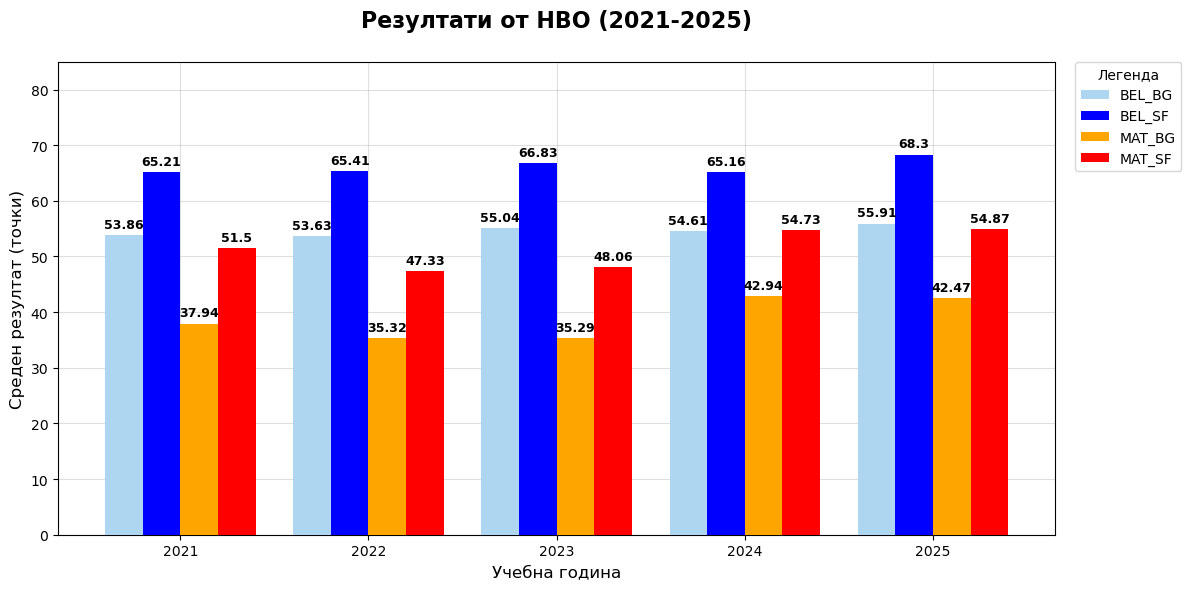

In [6]:
data = {
    'Year': [2021, 2022, 2023, 2024, 2025],
    'BEL_BG': [53.86, 53.63, 55.04, 54.61, 55.91],
    'BEL_SF': [65.21, 65.41, 66.83, 65.16, 68.3],
    'MAT_BG': [37.94, 35.32, 35.29, 42.94, 42.47],
    'MAT_SF': [51.5, 47.33, 48.06, 54.73, 54.87]
}

df = pd.DataFrame(data).set_index('Year')

# 2. Цветове :
my_colors = ['#AED6F1', 'blue', 'orange', 'red']

# 3. Плотиране на баровете
ax = df.plot(kind='bar', figsize=(12, 6), width=0.8, color=my_colors, zorder=3)

# 5. Добавяне на етикети (Data Labels)
for container in ax.containers:
    # Проверка дали контейнерът е за барове (а не за линиите)
    if hasattr(container, 'patches'):
        ax.bar_label(container, padding=3, fontsize=9, fontweight='bold')

# 6. Финално оформяне
plt.title('Резултати от НВО (2021-2025)', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('Среден резултат (точки)', fontsize=12)
plt.xlabel('Учебна година', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 85)
#plt.grid(axis='y', linestyle=':', alpha=0.5, zorder=1)
plt.grid(True, alpha=0.4)


# Легендата включва и баровете, и линиите
plt.legend(title="Легенда", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()


## Статистически данни за балообразуването

### Структура на балообразуването: 

#### НВО - БЕЛ : мин.'0', макс. 100 
#### НВО - МАТ : мин. '0', макс. 100

#### Схема на конвериране на оценките от дипломата в точки:


In [85]:

converted = { 
    'Диплома': [6, 5, 4, 3, 2], 
    'Точки': [50, 39, 26, 15, 0] 
}  
    
points = pd.DataFrame(converted)

In [91]:
points.set_index('Диплома').T   

Диплома,6,5,4,3,2
Точки,50,39,26,15,0


#### Селекция на училища със стандарно НВО (НВО-МАТ +  НВО-БЕЛ), без допълнително такова!

In [7]:
mask_regular = my_data['Балообразуване'].str.len() <=47
regular_schools = my_data[mask_regular].copy()
special_schools = my_data[~mask_regular].copy()

data_set = regular_schools.sort_values(by='Бал/2025', ascending=False) 

In [8]:
print(f"Брой на уникалните формули за балообразуване:   {len(regular_schools['Балообразуване'].unique())}") 

Брой на уникалните формули за балообразуване:   52


In [9]:
formula = regular_schools['Балообразуване'].value_counts()

score_formula = pd.DataFrame(formula).reset_index()  

score_formula.rename(columns={'count':'Брой паралелки за балообразуване'}, inplace=True)

### Разпределение на балообразувнето 

In [10]:

score_formula['Процент от всички балообразужщи формули'] = (
    score_formula['Брой паралелки за балообразуване'] / len(regular_schools) * 100
)

# 2.  форматиране
score_formula.style.format({
    'Процент от всички балообразужщи формули': '{:.2f}%'
})

,Балообразуване,Брой паралелки за балообразуване,Процент от всички балообразужщи формули
0,(2 * БЕЛ + 2 * МАТ) + (1 * БЕЛ + 1 * М),105,28.30%
1,(2 * БЕЛ + 2 * МАТ) + (1 * БЗО + 1 * ХООС),22,5.93%
2,(3 * БЕЛ + 1 * МАТ) + (1 * БЕЛ + 1 * ЧЕз),21,5.66%
3,(2 * БЕЛ + 2 * МАТ) + (1 * КМИТ + 1 * ЧЕз),21,5.66%
4,(3 * БЕЛ + 1 * МАТ) + (1 * ИИ + 1 * КМИТ),20,5.39%
5,(1 * БЕЛ + 3 * МАТ) + (1 * М + 1 * ФА),17,4.58%
6,(2 * БЕЛ + 2 * МАТ) + (1 * ГИ + 1 * КМИТ),12,3.23%
7,(2 * БЕЛ + 2 * МАТ) + (1 * ФА + 1 * КМИТ),12,3.23%
8,(2 * БЕЛ + 2 * МАТ) + (1 * М + 1 * КМИТ),7,1.89%
9,(2 * БЕЛ + 2 * МАТ) + (1 * ГИ + 1 * БЗО),7,1.89%


#### Информация за разпределението на паралелките в училищата според формулата за балообразуване

In [11]:
selected_features = regular_schools.drop(columns=['РАЙОН','Код на училището','Код на паралелката','Бал/2025'])

formula_used = selected_features.groupby(['Балообразуване', 'Училище - име']).value_counts() 
formula_frame = pd.DataFrame(formula_used) 

formula_frame

count
Балообразуване                             Училище - име                                      Паралелка - име                                          
(1 * БЕЛ + 3 * МАТ) + (1 * БЕЛ + 1 * ГИ)   СОФИЙСКА ГИМНАЗИЯ ПО СТРОИТЕЛСТВО, АРХИТЕКТУРА ... Брокер недвижими имоти - АЕ                             1
(1 * БЕЛ + 3 * МАТ) + (1 * БЕЛ + 1 * М)    Национална природо-математическа  гимназия "Ака... Математически - АЕ М Инф                                1
                                                                                              Математически - НЕ М Инф                                1
                                           Софийска математическа гимназия  "Паисий Хиленд... Математически (математика и информатика) - АЕ (...      1
                                                                                              Математически (математика и информатика) - НЕ (...      1
                                                                                              Математически (математика и физика) - АЕ (РИЧЕ)         1
                                                                                              Математически (математика и физика) - НЕ (ИИЧЕ)         1
(1 * БЕЛ + 3 * МАТ) + (1 * БЗО + 1 * ИИ)   СОФИЙСКА ГИМНАЗИЯ ПО СТРОИТЕЛСТВО, АРХИТЕКТУРА ... Парково строителство и озеленяване - АЕ                 1
(1 * БЕЛ + 3 * МАТ) + (1 * БЗО + 1 * ХООС) 95 СУ "Проф. Иван Шишманов", ГР.СОФИЯ              Природни науки - АЕ интензивно; РЕ                      1
(1 * БЕЛ + 3 * МАТ) + (1 * М + 1 * КМИТ)   ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ВИСОКИ ТЕХНОЛОГИИ "А.... Компютърни мрежи - АЕ  - разширено; втори ЧЕ - ...      1
                                                                                              Микропроцесорна техника АЕ - разширено; втори Ч...      1
                                                                                              Приложно програмиране - АЕ интензивно; втори ЧЕ...      1
                                                                                              Програмиране на изкуствен интелект - АЕ интензи...      1
                                                                                              Системно програмиране - АЕ интензивно; - втори ...      1
                                                                                              Телекомуникационни системи - АЕ - разширено; вт...      1
(1 * БЕЛ + 3 * МАТ) + (1 * М + 1 * ФА)     ПРОФЕСИОНАЛНА ГИМНАЗИЯ  ПО ТЕЛЕКОМУНИКАЦИИ, ГР.... Електронна търговия - АЕ                                1
                                                                                              Икономическа информатика - АЕ                           1
                                                                                              Компютърна техника и технологии - АЕ                    1
                                                                                              Компютърни мрежи - АЕ                                   1
                                                                                              Приложно програмиране - АЕ                              1
                                                                                              Системно програмиране - АЕ                              1
                                                                                              Телекомуникационни системи-АЕ                           1
                                           СОФИЙСКА ПРОФЕСИОНАЛНА  ГИМНАЗИЯ по ЕЛЕКТРОНИКА... Компютърна техника и технологии - АЕ, НЕ                1
                                                                                              Компютърни мрежи - АЕ, НЕ                               1
                                                                                              Приложно програмиране - АЕ, НЕ                          1
                                          

### Изчислявяне на бал в зависимост от балообразуващата формула

#### Въвеждане на данни (оценки от дипломата и точки от НВО)

In [12]:
while True:
    try:
        convertor = {6: 50, 5: 39, 4: 26, 3: 15, 2: 0}

        print("Въведи оценките от дипломата!")

        mat_d = int(input("Математика :"))
        bel_d = int(input("БЕЛ :"))
        fa_d = int(input("Физика :"))
        ic_d = int(input("История :"))
        kmit_d = int(input("Ком. моделиране и ИТ :"))
        chez_d = int(input("Чужд език :"))
        muz_d = int(input("Музика :"))
        ii_d = int(input("Изобразително искуство :"))
        bzo_d = int(input("Биология :"))
        geo_d = int(input("География :"))
        fvs_d = int(input("Физическо възпитание :"))
        hoos_d = int(input("Химия :"))
        tp_d = int(input("Технологии и предприемчество :"))


        if (
            mat_d in convertor.keys()
            and bel_d in convertor.keys()
            and fa_d in convertor.keys()
            and ic_d in convertor.keys()
            and kmit_d in convertor.keys()
            and chez_d in convertor.keys()
            and bzo_d in convertor.keys()
            and geo_d in convertor.keys()
            and fvs_d in convertor.keys()
            and hoos_d in convertor.keys()
            and tp_d in convertor.keys() 

            ): 
            mat = convertor[mat_d]
            bel = convertor[bel_d]
            fa = convertor[fa_d]
            ic = convertor[ic_d]
            kmit = convertor[kmit_d]
            chez = convertor[chez_d]
            muz = convertor[muz_d]
            bzo = convertor[bzo_d]
            geo = convertor[geo_d]
            fvs = convertor[fvs_d]
            hoos = convertor[hoos_d]
            tp = convertor[tp_d]
            ii = convertor[ii_d]


            break

    except (KeyError, ValueError):
        print("Въведи цяло число от 2 до 6!")


while True: 
    try: 
        MAT = float(input("НВО Математика:   "))
        BEL = float(input("НВО Български език и литература:   "))

        if 0 <= MAT <=100 and 0 <= BEL <= 100 : 
            break 

    except (ValueError, IndexError):
        print("Въведи оценките от НВО - (от 0 до 100)")

user_inputs = {
    'БЕЛ': BEL ,  # НВО БЕЛ (точки)
    'МАТ': MAT ,  # НВО МАТ (точки)
    'бел': bel ,     # Диплома БЕЛ (точки)
    'м': mat ,         # Диплома МАТ (точки)
    'бзо': bzo ,      # Биология
    'кмит': kmit ,      # ИТ
    'чез': chez ,     # Чужд език
    'ги': geo ,       # География.
    
    'хоос': hoos ,       # Химия
    'фа': fa ,         # Физика 
    'иц' : ic ,      # Истрория и цивилизация 
    'фвс': fvs ,     # Физическо възпитание и спорт 
    'муз': muz ,     # Музика 
    'ии': ii ,       # Изобразително искуство 
    'тп': tp         # Технологии и предприемачество
} 

Въведи оценките от дипломата!


Математика : 5
БЕЛ : 5
Физика : 6
История : 4
Ком. моделиране и ИТ : 5
Чужд език : 5
Музика : 5
Изобразително искуство : 6
Биология : 5
География : 4
Физическо възпитание : 6
Химия : 5
Технологии и предприемчество : 4
НВО Математика:    54
НВО Български език и литература:    60.12


#### Изчислявяне на бал.

In [13]:
def calculate_user_score(formula_str, inputs):

    # Правим всичко след първия блок скоби в малки букви
    idx = formula_str.find(') + (') + 4
    clean_formula = formula_str[:idx-4] + formula_str[idx-4:].lower()
    
    try:
        # Използваме eval, като подаваме user_inputs като контекст
        return eval(clean_formula, {"__builtins__": None}, inputs)
    except Exception as e:
        return f"Грешка във формулата: {e}"


data_set['Вашият бал'] = data_set['Балообразуване'].apply(
    lambda x: calculate_user_score(x, user_inputs))


#pd.set_option('display.max_rows', None) 
        
cols = ['РАЙОН', 'Код на училището', 'Училище - име', 'Код на паралелката',
       'Паралелка - име', 'Балообразуване', 'Бал/2025', 'Вашият бал']
data_set = data_set[cols] 

# Почистваме даннита от евнтуални гешки на служителаката на МОН

data_set['Бал/2025'] = pd.to_numeric(data_set['Бал/2025'].astype(str).str.replace(',', '.'), errors='coerce')
data_set['Вашият бал'] = pd.to_numeric(data_set['Вашият бал'].astype(str).str.replace(',', '.'), errors='coerce')
data_set = data_set.dropna(subset=['Бал/2025', 'Вашият бал'])


data_set_filtered = data_set[data_set['Вашият бал'] >= data_set['Бал/2025']]
my_set = data_set_filtered.sort_values(by=['Вашият бал'], ascending=False)

#### Изчисляване на бал по училища и паралелки ( специалности ) 

In [14]:
pd.set_option('display.max_rows', None)

my_set.sort_values(by=['Вашият бал'], ascending=False).reset_index(drop='index')         

,РАЙОН,Код на училището,Училище - име,Код на паралелката,Паралелка - име,Балообразуване,Бал/2025,Вашият бал
0,ИЗГРЕВ,2205408.0,"Софийска професионална гимназия ""Княгиня Евдо...",4290,"Театрален, кино и телевизионен декор - АЕ",(3 * БЕЛ + 1 * МАТ) + (1 * ИИ + 1 * КМИТ),322.00,323.36
1,МЛАДОСТ,2213081.0,"81. Средно училище ""Виктор Юго"", ГР.СОФИЯ",2579,Хуманитарни науки,(3 * БЕЛ + 1 * МАТ) + (1 * БЕЛ + 1 * ФВС),313.50,323.36
2,ИЗГРЕВ,2205408.0,"Софийска професионална гимназия ""Княгиня Евдо...",2843,Фризьорство,(3 * БЕЛ + 1 * МАТ) + (1 * БЗО + 1 * ИИ),307.25,323.36
3,ЛОЗЕНЕЦ,2211417.0,"Професионална гимназия по облекло ""Княгиня Ма...",491,"Конструиране, моделиране и технология на облек...",(3 * БЕЛ + 1 * МАТ) + (1 * ИИ + 1 * КМИТ),306.00,323.36
4,ИЗГРЕВ,2205408.0,"Софийска професионална гимназия ""Княгиня Евдо...",2845,Козметика,(3 * БЕЛ + 1 * МАТ) + (1 * БЗО + 1 * ИИ),306.00,323.36
5,ИЗГРЕВ,2205408.0,"Софийска професионална гимназия ""Княгиня Евдо...",4292,"Художествено осветление за театър, кино и теле...",(3 * БЕЛ + 1 * МАТ) + (1 * ИИ + 1 * КМИТ),304.00,323.36
6,КРАСНО СЕЛО,2209132.0,"132. Средно училище ""Ваня Войнова"", ГР.СОФИЯ",4283,Пространствен дизайн,(3 * БЕЛ + 1 * МАТ) + (1 * ИИ + 1 * КМИТ),299.75,323.36
7,ВЪЗРАЖДАНЕ,2204403.0,ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ТЕКСТИЛНИ И КОЖЕНИ ...,3251,Моден дизайн - АЕ,(3 * БЕЛ + 1 * МАТ) + (1 * ИИ + 1 * КМИТ),273.50,323.36
8,ВЪЗРАЖДАНЕ,2204403.0,ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ТЕКСТИЛНИ И КОЖЕНИ ...,4825,Сценичен костюм,(3 * БЕЛ + 1 * МАТ) + (1 * ИИ + 1 * КМИТ),54.00,323.36
9,ВЪЗРАЖДАНЕ,2204403.0,ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ТЕКСТИЛНИ И КОЖЕНИ ...,4274,Организация и технология на козметичните услуги,(3 * БЕЛ + 1 * МАТ) + (1 * БЗО + 1 * ИИ),91.00,323.36


#### Изчисляване на най-висок , най-нисък и среден постигнат бал

In [15]:
my_set.columns

Index(['РАЙОН', 'Код на училището', 'Училище - име', 'Код на паралелката',
       'Паралелка - име', 'Балообразуване', 'Бал/2025', 'Вашият бал'],
      dtype='object')

In [16]:
dfr = pd.DataFrame(my_set['Вашият бал'].describe())  
data_frame = dfr.T  
data_frame.columns

Index(['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'], dtype='object')

In [17]:
data_frame.rename(columns={'count':'брои приеми', 'mean':'средна стойност', 'std':'ст. отклонение', 
                           'min': 'мин. стойност', 'max':'макс. стойност'}, inplace=True) 
data_frame.T 

,Вашият бал
брои приеми,181.000000
средна стойност,306.319558
ст. отклонение,8.833855
мин. стойност,280.240000
25%,300.120000
50%,306.240000
75%,312.360000
макс. стойност,323.360000


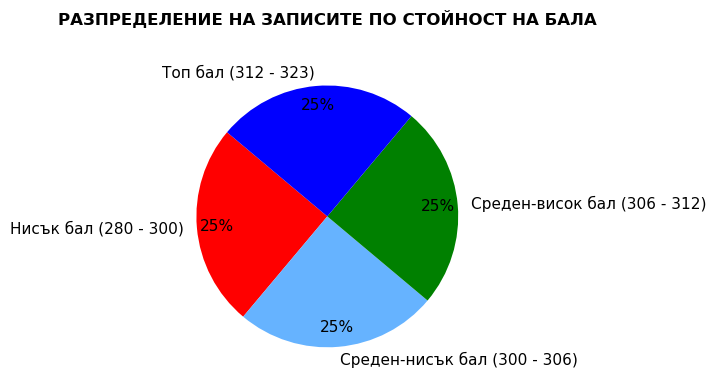

In [18]:
# 1. Вземаме стойностите за границите на квартилите  транспониран DataFrame
# Използваме оригиналните индекси 'min', '25%', '50%', '75%', 'макс. стойност'
min_val = data_frame.at['Вашият бал', 'мин. стойност']
q1 = data_frame.at['Вашият бал', '25%']
q2 = data_frame.at['Вашият бал', '50%']
q3 = data_frame.at['Вашият бал', '75%']
max_val = data_frame.at['Вашият бал', 'макс. стойност']

# 2. Създаваме ясни етикети (Labels), които показват обхвата на всяка група
labels = [
    f'Нисък бал ({min_val:.0f} - {q1:.0f})',
    f'Среден-нисък бал ({q1:.0f} - {q2:.0f})',
    f'Среден-висок бал ({q2:.0f} - {q3:.0f})',
    f'Топ бал ({q3:.0f} - {max_val:.0f})'
]

# Тъй като това са квартили, всяка група съдържа точно 25% 
sizes = [25, 25, 25, 25] 


colors = ['red', '#66b3ff', 'green', 'blue']

# 3. Настройки на графиката
plt.figure(figsize=(6, 4))
plt.title('РАЗПРЕДЕЛЕНИЕ НА ЗАПИСИТЕ ПО СТОЙНОСТ НА БАЛА', pad=20, fontsize=12, fontweight='bold')

# Изчертаване на пай чарта
plt.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    autopct='%1.0f%%',       # Показва процентите (всички ще са 25%)
    startangle=140,          # Завърта графиката за по-добра визия
    pctdistance=0.85,        # Позиция на процентите навътре в парчетата
    textprops={'fontsize': 11} # Размер на текста
)

plt.tight_layout()
plt.show()


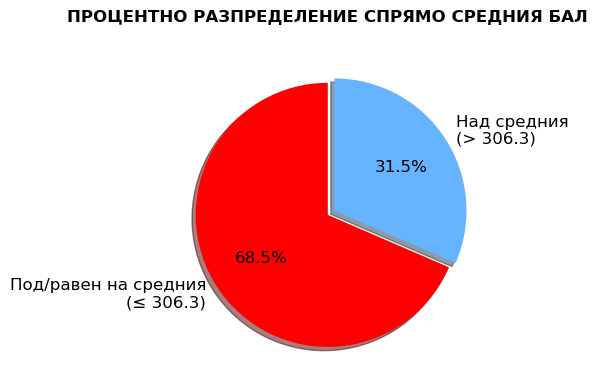

In [19]:
# 1. Вземаме изчислената средна стойност от  DataFrame
mean_value = data_frame.at['Вашият бал', 'средна стойност']

# 2. Изчисляваме броя на записите под и над средната стойност
below_mean = (my_set['Вашият бал'] <= mean_value).sum()
above_mean = (my_set['Вашият бал'] > mean_value).sum()

# Подготвяме данните за пай чарта
sizes = [below_mean, above_mean]
labels = [
    f'Под/равен на средния\n(≤ {mean_value:.1f})', 
    f'Над средния\n(> {mean_value:.1f})'
]

# Избор на контрастни цветове (например: меко червено и приятно зелено/синьо)
colors = ['red', '#66b3ff'] 

# Леко отделяне на парчето с по-висок бал за акцент
explode = (0, 0.06) 

# 3. Настройки на графиката
plt.figure(figsize=(8, 4))
plt.title('ПРОЦЕНТНО РАЗПРЕДЕЛЕНИЕ СПРЯМО СРЕДНИЯ БАЛ', pad=20, fontsize=12, fontweight='bold')

# Изчертаване на пай чарта
plt.pie(
    sizes, 
    explode=explode,
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%',       # Показва точния процент (напр. 48.5%)
    startangle=90,           # Започва вертикално отгоре
    shadow=True,             # Добавя лека сянка за обем
    textprops={'fontsize': 12} 
)

plt.tight_layout()
plt.show()

In [20]:
my_set['Вашият бал'].mode() # Постигнат бал с най-много записис

0    306.24
Name: Вашият бал, dtype: float64

In [21]:
x = my_set['Вашият бал'].value_counts() 
counts = pd.DataFrame(x) 

In [22]:
counts.rename(columns={'count': 'Брой записи'}, inplace=True)
counts.reset_index()  


,Вашият бал,Брой записи
0,306.24,74
1,312.36,25
2,293.24,21
3,299.36,16
4,317.24,15
5,323.36,13
6,300.12,7
7,311.12,4
8,280.24,3
9,286.36,2


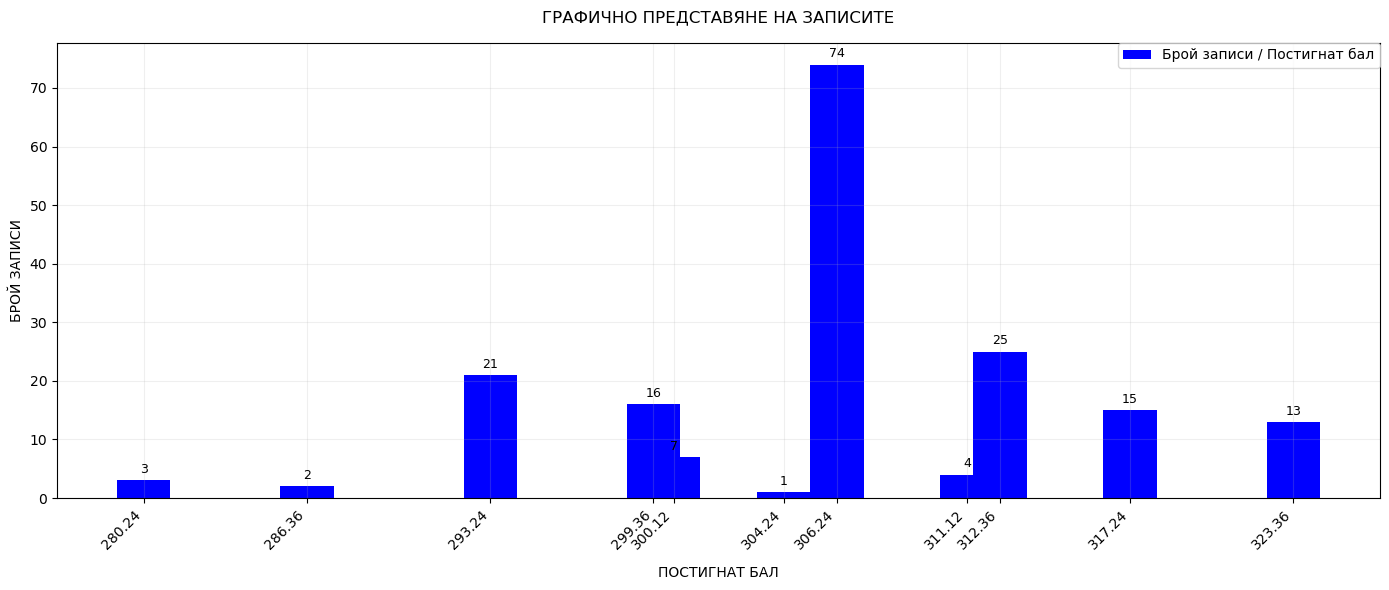

In [23]:

counts = my_set['Вашият бал'].value_counts().sort_index()
x_values = counts.index
y_values = counts.values

plt.figure(figsize=(14, 6))
plt.title('ГРАФИЧНО ПРЕДСТАВЯНЕ НА ЗАПИСИТЕ', pad=15, loc='center') 

# 2. Чертане на баровете
bars = plt.bar(x_values, y_values, width=2, align='center', color='b',
               label='Брой записи / Постигнат бал')

plt.xlabel('ПОСТИГНАТ БАЛ', labelpad=10) 
plt.ylabel('БРОЙ ЗАПИСИ')

# 3. Завъртане на етикетите по оста X на 45 градуса
plt.xticks(x_values, rotation=45, ha='right') 


plt.bar_label(bars, label_type='edge', padding=3, fontsize=9)


plt.legend(loc='best', borderaxespad=0)
plt.grid(True, alpha=0.2)
plt.tight_layout() 
plt.show()


### Информация за балообразуващата формула , кореспондираща с постигнатия бал

#### Показва всички (само уникални) комбинации на формулата за балообразуване при постигането на конкретен бал 

In [24]:

# 1. Конвертираме към Polars
my_set_pl = pl.from_pandas(my_set)

# 2. Вземаме само уникалните комбинации от двете колони
df_unique_pl = (
    my_set_pl.select(['Вашият бал', 'Балообразуване'])
    .unique()
    .sort('Вашият бал', descending=True) # Опционално: сортираме от най-висок към най-нисък бал
)


In [25]:
df_unique_pl.count

<bound method DataFrame.count of shape: (42, 2)
┌────────────┬────────────────────────────────────────────┐
│ Вашият бал ┆ Балообразуване                             │
│ ---        ┆ ---                                        │
│ f64        ┆ str                                        │
╞════════════╪════════════════════════════════════════════╡
│ 323.36     ┆ (3 * БЕЛ + 1 * МАТ) + (1 * ФВС + 1 * ЧЕз)  │
│ 323.36     ┆ (3 * БЕЛ + 1 * МАТ) + (1 * БЕЛ + 1 * ФВС)  │
│ 323.36     ┆ (3 * БЕЛ + 1 * МАТ) + (1 * ИИ + 1 * КМИТ)  │
│ 323.36     ┆ (3 * БЕЛ + 1 * МАТ) + (1 * БЗО + 1 * ИИ)   │
│ 323.36     ┆ (3 * БЕЛ + 1 * МАТ) + (1 * БЕЛ + 1 * ИИ)   │
│ 317.24     ┆ (2 * БЕЛ + 2 * МАТ) + (1 * ФА + 1 * КМИТ)  │
│ 317.24     ┆ (2 * БЕЛ + 2 * МАТ) + (1 * ИИ + 1 * КМИТ)  │
│ 317.24     ┆ (2 * БЕЛ + 2 * МАТ) + (1 * М + 1 * ФА)     │
│ 317.24     ┆ (2 * БЕЛ + 2 * МАТ) + (1 * БЕЛ + 1 * ИИ)   │
│ 312.36     ┆ (3 * БЕЛ + 1 * МАТ) + (1 * БЕЛ + 1 * КМИТ) │
│ 312.36     ┆ (3 * БЕЛ + 1 * МАТ) + (1 * БЕЛ + 1 * 

#### Разпределение на резултатите по райони (Общини) и по училища 

In [26]:
dff = pd.DataFrame(my_set['РАЙОН'].value_counts())  

In [27]:
dff.rename(columns={'count': 'Брой записи'}, inplace=True) 
dff.reset_index()  

,РАЙОН,Брой записи
0,ИЛИНДЕН,28
1,ЛЮЛИН,19
2,ОВЧА КУПЕЛ,15
3,МЛАДОСТ,13
4,ИСКЪР,10
5,ПОДУЯНЕ,9
6,КРАСНА ПОЛЯНА,9
7,ОБОРИЩЕ,9
8,СЛАТИНА,8
9,ИЗГРЕВ,8


#### Разпределение по училища

In [28]:
dfs = pd.DataFrame(my_set['Училище - име'].value_counts())  

In [29]:
dfs.rename(columns={'count': 'Брой записи'}, inplace=True) 
dfs

,Брой записи
Училище - име,
"Професионална гимназия по транспорт и енергетика ""Хенри Форд"", ГР.СОФИЯ",12
"Софийска професионална гимназия ""Княгиня Евдокия"", ГР.СОФИЯ",8
"СОФИЙСКА ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ТУРИЗЪМ, ГР.СОФИЯ",7
"ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ТРАНСПОРТ ""МАКГАХАН"", ГР.СОФИЯ",6
"ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ВИСОКИ ТЕХНОЛОГИИ ""А. С. ПОПОВ"", ГР.СОФИЯ",6
"33. Езикова гимназия ""Света София"", ГР.СОФИЯ",5
"ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ТЕКСТИЛНИ И КОЖЕНИ ИЗДЕЛИЯ, ГР.СОФИЯ",5
"ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ЕЛЕКТРОТЕХНИКА И АВТОМАТИКА, ГР.СОФИЯ",5
"Професионална гимназия по екология и биотехнологии ""Проф. д-р Асен Златаров"", ГР.СОФИЯ",4


### Филтриране на данните по избрани критерии 

#### Добавяне на разлика между бал от предходхата година и постигнат бал 

In [30]:

my_set['Разлика'] = my_set['Вашият бал'] - my_set['Бал/2025']
final_set = my_set.sort_values(by=['Вашият бал'], ascending=False).reset_index() 


### Селекция на районите (общини) 

#### Избор на райони, които ни интересуват (критерий - отдалаченост) 

#### Сортираме резултатите по райиони (Общини)

In [31]:
selected_locations = ['ИЗГРЕВ', 'СЛАТИНА', 'СТУДЕНТСКИ', 'ОБОРИЩЕ', 'МЛАДОСТ', 'ИСКЪР','ТРИАДИЦА','ЛОЗЕНЕЦ','ВЪЗРАЖДАНЕ' ] 
selections = my_set[my_set['РАЙОН'].isin(selected_locations)] 

In [32]:
selections.columns

Index(['РАЙОН', 'Код на училището', 'Училище - име', 'Код на паралелката',
       'Паралелка - име', 'Балообразуване', 'Бал/2025', 'Вашият бал',
       'Разлика'],
      dtype='object')

In [33]:
selections = selections.drop(columns=['Код на училището', 'Код на паралелката','Балообразуване'])  

In [34]:
sorted_selections = selections.sort_values(by=['РАЙОН']).reset_index(drop='index')

In [35]:
sorted_selections 

,РАЙОН,Училище - име,Паралелка - име,Бал/2025,Вашият бал,Разлика
0,ВЪЗРАЖДАНЕ,ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ТЕКСТИЛНИ И КОЖЕНИ ...,Организация на туризма и свободното време - АЕ,89.00,286.36,197.36
1,ВЪЗРАЖДАНЕ,"ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ПОДЕМНА, СТРОИТЕЛНА ...",Ръководител движение - АЕ,58.00,306.24,248.24
2,ВЪЗРАЖДАНЕ,"ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ПОДЕМНА, СТРОИТЕЛНА ...",Локомотиви и вагони (дуална) - РЕ,44.00,306.24,262.24
3,ВЪЗРАЖДАНЕ,"ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ПОДЕМНА, СТРОИТЕЛНА ...",Пътно-строителна техника - АЕ,30.00,306.24,276.24
4,ВЪЗРАЖДАНЕ,ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ТЕКСТИЛНИ И КОЖЕНИ ...,Моден дизайн - АЕ,273.50,323.36,49.86
5,ВЪЗРАЖДАНЕ,ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ТЕКСТИЛНИ И КОЖЕНИ ...,Сценичен костюм,54.00,323.36,269.36
6,ВЪЗРАЖДАНЕ,ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ТЕКСТИЛНИ И КОЖЕНИ ...,Организация и технология на козметичните услуги,91.00,323.36,232.36
7,ВЪЗРАЖДАНЕ,ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ТЕКСТИЛНИ И КОЖЕНИ ...,Бутикови облекла,213.50,323.36,109.86
8,ИЗГРЕВ,"Софийска професионална гимназия ""Княгиня Евдо...",Индустриални отношения - АЕ,275.75,299.36,23.61
9,ИЗГРЕВ,"Софийска професионална гимназия ""Княгиня Евдо...",Икономическо информационно осигуряване - АЕ,257.00,306.24,49.24


#### Селекция на паралелките по бал с най-много записи, като минимален праг.

#### Минималният праг може да бъде и друга (произволна) стойност. 

#### Данните са сортирани по най-малка разлика - (постигнат бал / бал-2025)

#### Удобно е за подреба на желаните паралелки преди първото калсиране

In [36]:
my_list = my_set['Вашият бал'].to_list()
x = st.mode(my_list) 

In [37]:
print(f" Постигнат бал с най-много записи: {x:.2f} ")

 Постигнат бал с най-много записи: 306.24 


In [38]:
sel = selections['Вашият бал'] >= x # Възможно е да се използва произволно иабран праг за селекция
best = selections[sel] 

In [39]:
best.sort_values(by=['Разлика']).reset_index(drop='index') 

,РАЙОН,Училище - име,Паралелка - име,Бал/2025,Вашият бал,Разлика
0,ИЗГРЕВ,"Софийска професионална гимназия ""Княгиня Евдо...","Театрален, кино и телевизионен декор - АЕ",322.00,323.36,1.36
1,СТУДЕНТСКИ,"ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ТЕЛЕКОМУНИКАЦИИ, ГР...",Електронна търговия - АЕ,301.50,311.12,9.62
2,МЛАДОСТ,"81. Средно училище ""Виктор Юго"", ГР.СОФИЯ",Хуманитарни науки,313.50,323.36,9.86
3,СТУДЕНТСКИ,"ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ТЕЛЕКОМУНИКАЦИИ, ГР...",Компютърна техника и технологии - АЕ,300.50,311.12,10.62
4,ИЗГРЕВ,"Софийска професионална гимназия ""Княгиня Евдо...",Фризьорство,307.25,323.36,16.11
5,ИЗГРЕВ,"Софийска професионална гимназия ""Княгиня Евдо...",Козметика,306.00,323.36,17.36
6,ЛОЗЕНЕЦ,"Професионална гимназия по облекло ""Княгиня Ма...","Конструиране, моделиране и технология на облек...",306.00,323.36,17.36
7,ИЗГРЕВ,"Софийска професионална гимназия ""Княгиня Евдо...","Художествено осветление за театър, кино и теле...",304.00,323.36,19.36
8,СТУДЕНТСКИ,"ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ТЕЛЕКОМУНИКАЦИИ, ГР...",Телекомуникационни системи-АЕ,287.50,311.12,23.62
9,МЛАДОСТ,"118 Средно училище ""Академик Людмил Стоянов"",...","Софтуерни и хардуерни науки - АЕ интензивно, ИЕ",279.00,306.24,27.24


#### Представяне на всички данни (записи) като списък: 

##### Списъка съдържа абсолютно всички детайли от таблиците

##### Данните са сортирани по най-висок постигнат бал (намаляващ)

##### Опция! Може да покаже пълният списък, или определен брой (първите 50 -примерно)

In [40]:
print(f"Пълен списък (брой): {len(my_set)}")

Пълен списък (брой): 181


In [41]:

for _, row in my_set[:50].sort_values(by=['Вашият бал'], ascending=False).iterrows(): # Брой записи 50 в случая :50 
    print(row)
    print() 
    print() 

РАЙОН                                                            ИЗГРЕВ
Код на училището                                              2205408.0
Училище - име         Софийска професионална гимназия  "Княгиня Евдо...
Код на паралелката                                                 4290
Паралелка - име               Театрален, кино и телевизионен декор - АЕ
Балообразуване                (3 * БЕЛ + 1 * МАТ) + (1 * ИИ + 1 * КМИТ)
Бал/2025                                                          322.0
Вашият бал                                                       323.36
Разлика                                                            1.36
Name: 187, dtype: object


РАЙОН                                                    МЛАДОСТ
Код на училището                                       2213081.0
Училище - име         81. Средно училище  "Виктор Юго", ГР.СОФИЯ
Код на паралелката                                          2579
Паралелка - име                                Хуманитарни науки


### Селекция на избрани училища

#### Списък на училищата:

In [42]:
polars_schools_list = pl.from_pandas(my_set['Училище - име']) 

In [43]:
polars_schools_list.value_counts().count  

<bound method DataFrame.count of shape: (71, 2)
┌─────────────────────────────────────────────────────────────────────────────────────────────┬───────┐
│ Училище - име                                                                               ┆ count │
│ ---                                                                                         ┆ ---   │
│ str                                                                                         ┆ u32   │
╞═════════════════════════════════════════════════════════════════════════════════════════════╪═══════╡
│ 44. Средно училище "Неофит Бозвели", ГР.СОФИЯ                                               ┆ 2     │
│ 29. Средно училище  "Кузман Шапкарев", ГР.СОФИЯ                                             ┆ 1     │
│ 39 Средно училище "Петър Динеков", ГР.СОФИЯ                                                 ┆ 3     │
│ 68. Средно училище "Академик Никола Обрешков", ГР.СОФИЯ                                     ┆ 3     │
│ 8. Средно учил

####  Избор на училища :

In [44]:
selected_schools = ['203 Профилирана езикова гимназия "Свети Методий", ГР.СОФИЯ', 
                    'НАЦИОНАЛНА ПРОФЕСИОНАЛНА ГИМНАЗИЯ  ПО ПРЕЦИЗНА ТЕХНИКА И ОПТИКА "М. В. Ломоносов", ГР.СОФИЯ', 
                    'Софийска професионална гимназия  "Княгиня Евдокия", ГР.СОФИЯ',
                    'Професионална гимназия по облекло  "Княгиня Мария Луиза", ГР.СОФИЯ','27. Средно училище "Акад. Георги Караславов", ГР.СОФИЯ',
                   'ПРОФЕСИОНАЛНА ГИМНАЗИЯ  ПО ТЕЛЕКОМУНИКАЦИИ, ГР.СОФИЯ'] 

schools = my_set[my_set['Училище - име'].isin(selected_schools)] 
polars_schools = pl.from_pandas(schools)

In [45]:
polars_schools

РАЙОН,Код на училището,Училище - име,Код на паралелката,Паралелка - име,Балообразуване,Бал/2025,Вашият бал,Разлика
str,f64,str,i64,str,str,f64,f64,f64
"""ИЗГРЕВ""",2.205408e6,"""Софийска професионална гимназия ""Княгиня Евдокия"", ГР.СОФИЯ""",4290,"""Театрален, кино и телевизионен декор - АЕ""","""(3 * БЕЛ + 1 * МАТ) + (1 * ИИ + 1 * КМИТ)""",322.0,323.36,1.36
"""ИЗГРЕВ""",2.205408e6,"""Софийска професионална гимназия ""Княгиня Евдокия"", ГР.СОФИЯ""",2843,"""Фризьорство""","""(3 * БЕЛ + 1 * МАТ) + (1 * БЗО + 1 * ИИ)""",307.25,323.36,16.11
"""ЛОЗЕНЕЦ""",2.211417e6,"""Професионална гимназия по облекло ""Княгиня Мария Луиза"", ГР.СОФИЯ""",491,"""Конструиране, моделиране и технология на облекло от текстил - АЕ, ФЕ""","""(3 * БЕЛ + 1 * МАТ) + (1 * ИИ + 1 * КМИТ)""",306.0,323.36,17.36
"""ИЗГРЕВ""",2.205408e6,"""Софийска професионална гимназия ""Княгиня Евдокия"", ГР.СОФИЯ""",2845,"""Козметика""","""(3 * БЕЛ + 1 * МАТ) + (1 * БЗО + 1 * ИИ)""",306.0,323.36,17.36
"""ИЗГРЕВ""",2.205408e6,"""Софийска професионална гимназия ""Княгиня Евдокия"", ГР.СОФИЯ""",4292,"""Художествено осветление за театър, кино и телевизия - АЕ""","""(3 * БЕЛ + 1 * МАТ) + (1 * ИИ + 1 * КМИТ)""",304.0,323.36,19.36
"""ИЗГРЕВ""",2.205408e6,"""Софийска професионална гимназия ""Княгиня Евдокия"", ГР.СОФИЯ""",3381,"""Промишлен дизайн - АЕ""","""(2 * БЕЛ + 2 * МАТ) + (1 * ИИ + 1 * КМИТ)""",285.0,317.24,32.24
"""ИЗГРЕВ""",2.205408e6,"""Софийска професионална гимназия ""Княгиня Евдокия"", ГР.СОФИЯ""",2842,"""Извършване на термални процедури - АЕ""","""(3 * БЕЛ + 1 * МАТ) + (1 * БЗО + 1 * ЧЕз)""",245.5,312.36,66.86
"""КРАСНО СЕЛО""",2.209305e6,"""203 Профилирана езикова гимназия ""Свети Методий"", ГР.СОФИЯ""",3271,"""Природни науки - АЕ интензивно, ИЕ или НЕ""","""(3 * БЕЛ + 1 * МАТ) + (1 * БЕЛ + 1 * БЗО)""",306.5,312.36,5.86
"""СТУДЕНТСКИ""",2.223431e6,"""ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ТЕЛЕКОМУНИКАЦИИ, ГР.СОФИЯ""",707,"""Електронна търговия - АЕ""","""(1 * БЕЛ + 3 * МАТ) + (1 * М + 1 * ФА)""",301.5,311.12,9.62


#### Проверка на паралелките за конкретно балообразуване 

In [46]:
choise = my_set['Балообразуване'] == '(2 * БЕЛ + 2 * МАТ) + (1 * БЕЛ + 1 * М)'
choise_formula = my_set[choise].copy() 

In [47]:
polars_set = pl.from_pandas(choise_formula) 

In [48]:
polars_set

РАЙОН,Код на училището,Училище - име,Код на паралелката,Паралелка - име,Балообразуване,Бал/2025,Вашият бал,Разлика
str,f64,str,i64,str,str,f64,f64,f64
"""НАДЕЖДА""",2.214015e6,"""15 Средно училище "" Адам Мицкевич"", ГР.СОФИЯ""",3015,"""Митническо и данъчно обслужване - АЕ""","""(2 * БЕЛ + 2 * МАТ) + (1 * БЕЛ + 1 * М)""",30.0,306.24,276.24
"""ВЪЗРАЖДАНЕ""",2.204405e6,"""ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ПОДЕМНА, СТРОИТЕЛНА И ТРАНСПОРТНА ТЕХНИКА, ГР.СОФИЯ""",2524,"""Пътно-строителна техника - АЕ""","""(2 * БЕЛ + 2 * МАТ) + (1 * БЕЛ + 1 * М)""",30.0,306.24,276.24
"""НАДЕЖДА""",2.214015e6,"""15 Средно училище "" Адам Мицкевич"", ГР.СОФИЯ""",2582,"""Предприемачески - АЕ""","""(2 * БЕЛ + 2 * МАТ) + (1 * БЕЛ + 1 * М)""",36.0,306.24,270.24
"""ВЪЗРАЖДАНЕ""",2.204405e6,"""ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ПОДЕМНА, СТРОИТЕЛНА И ТРАНСПОРТНА ТЕХНИКА, ГР.СОФИЯ""",3558,"""Локомотиви и вагони (дуална) - РЕ""","""(2 * БЕЛ + 2 * МАТ) + (1 * БЕЛ + 1 * М)""",44.0,306.24,262.24
"""ВЪЗРАЖДАНЕ""",2.204405e6,"""ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ПОДЕМНА, СТРОИТЕЛНА И ТРАНСПОРТНА ТЕХНИКА, ГР.СОФИЯ""",3562,"""Ръководител движение - АЕ""","""(2 * БЕЛ + 2 * МАТ) + (1 * БЕЛ + 1 * М)""",58.0,306.24,248.24
"""СЛАТИНА""",2.22143e6,"""ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ТРАНСПОРТ ""МАКГАХАН"", ГР.СОФИЯ""",2212,"""Спедиция транспортна и складова логистика - АЕ (дуална)""","""(2 * БЕЛ + 2 * МАТ) + (1 * БЕЛ + 1 * М)""",71.0,306.24,235.24
"""НАДЕЖДА""",2.214015e6,"""15 Средно училище "" Адам Мицкевич"", ГР.СОФИЯ""",4438,"""Митническо и данъчно обслужване""","""(2 * БЕЛ + 2 * МАТ) + (1 * БЕЛ + 1 * М)""",78.0,306.24,228.24
"""МЛАДОСТ""",2.213081e6,"""81. Средно училище ""Виктор Юго"", ГР.СОФИЯ""",2566,"""Чужди езици - АЕ интензивно""","""(2 * БЕЛ + 2 * МАТ) + (1 * БЕЛ + 1 * М)""",275.5,306.24,30.74
"""ИЛИНДЕН""",2.212303e6,"""33. Езикова гимназия ""Света София"", ГР.СОФИЯ""",2767,"""Чужди езици - АЕ интензивно, КитЕ/ГрЕ""","""(2 * БЕЛ + 2 * МАТ) + (1 * БЕЛ + 1 * М)""",269.5,306.24,36.74


### Брой записи - балообразувне:

In [49]:
polars_schools_all = pl.from_pandas(my_set) 

In [50]:
polars_schools_all ['Балообразуване'].value_counts().count 

<bound method DataFrame.count of shape: (42, 2)
┌────────────────────────────────────────────┬───────┐
│ Балообразуване                             ┆ count │
│ ---                                        ┆ ---   │
│ str                                        ┆ u32   │
╞════════════════════════════════════════════╪═══════╡
│ (1 * БЕЛ + 3 * МАТ) + (1 * М + 1 * КМИТ)   ┆ 6     │
│ (1 * БЕЛ + 3 * МАТ) + (1 * БЗО + 1 * ХООС) ┆ 1     │
│ (3 * БЕЛ + 1 * МАТ) + (1 * КМИТ + 1 * ЧЕз) ┆ 5     │
│ (2 * БЕЛ + 2 * МАТ) + (1 * ГИ + 1 * КМИТ)  ┆ 7     │
│ (2 * БЕЛ + 2 * МАТ) + (1 * М + 1 * ФА)     ┆ 1     │
│ (3 * БЕЛ + 1 * МАТ) + (1 * БЕЛ + 1 * М)    ┆ 2     │
│ (2 * БЕЛ + 2 * МАТ) + (1 * ГИ + 1 * ЧЕз)   ┆ 2     │
│ (3 * БЕЛ + 1 * МАТ) + (1 * ГИ + 1 * КМИТ)  ┆ 5     │
│ (2 * БЕЛ + 2 * МАТ) + (1 * М + 1 * КМИТ)   ┆ 6     │
│ (3 * БЕЛ + 1 * МАТ) + (1 * ФВС + 1 * ЧЕз)  ┆ 1     │
│ (3 * БЕЛ + 1 * МАТ) + (1 * ИИ + 1 * КМИТ)  ┆ 7     │
│ (3 * БЕЛ + 1 * МАТ) + (1 * БЕЛ + 1 * ЧЕз)  ┆ 7     │
│ (2 * БЕЛ + 2 * 

In [51]:
my_set.columns

Index(['РАЙОН', 'Код на училището', 'Училище - име', 'Код на паралелката',
       'Паралелка - име', 'Балообразуване', 'Бал/2025', 'Вашият бал',
       'Разлика'],
      dtype='object')

In [52]:
score_count_frame = my_set.drop(columns=['РАЙОН', 'Код на училището', 'Код на паралелката',
                                         'Бал/2025', 'Разлика']) 

In [53]:
score_count = pd.DataFrame(score_count_frame)

In [54]:
Y = score_count.groupby([ 'Балообразуване', 'Вашият бал']).value_counts() 

In [55]:
Y_grouped = pd.DataFrame(Y) 

In [56]:
Y_grouped 

count
Балообразуване                             Вашият бал Училище - име                                      Паралелка - име                                          
(1 * БЕЛ + 3 * МАТ) + (1 * БЗО + 1 * ХООС) 300.12     95 СУ "Проф. Иван Шишманов", ГР.СОФИЯ              Природни науки - АЕ интензивно; РЕ                      1
(1 * БЕЛ + 3 * МАТ) + (1 * М + 1 * КМИТ)   300.12     ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ВИСОКИ ТЕХНОЛОГИИ "А.... Компютърни мрежи - АЕ  - разширено; втори ЧЕ - ...      1
                                                                                                         Микропроцесорна техника АЕ - разширено; втори Ч...      1
                                                                                                         Приложно програмиране - АЕ интензивно; втори ЧЕ...      1
                                                                                                         Програмиране на изкуствен интелект - АЕ интензи...      1
                                                                                                         Системно програмиране - АЕ интензивно; - втори ...      1
                                                                                                         Телекомуникационни системи - АЕ - разширено; вт...      1
(1 * БЕЛ + 3 * МАТ) + (1 * М + 1 * ФА)     311.12     ПРОФЕСИОНАЛНА ГИМНАЗИЯ  ПО ТЕЛЕКОМУНИКАЦИИ, ГР.... Електронна търговия - АЕ                                1
                                                                                                         Икономическа информатика - АЕ                           1
                                                                                                         Компютърна техника и технологии - АЕ                    1
                                                                                                         Телекомуникационни системи-АЕ                           1
(2 * БЕЛ + 2 * МАТ) + (1 * БЕЛ + 1 * БЗО)  306.24     130. средно училище "Стефан Караджа", ГР.СОФИЯ     Помощник-възпитател                                     1
                                                      ПРОФЕСИОНАЛНА ГИМНАЗИЯ "Д-Р СТАМЕН ГРИГОРОВ", Г... Помощник - възпитател в отглеждането и възпитан...      1
(2 * БЕЛ + 2 * МАТ) + (1 * БЕЛ + 1 * ГИ)   293.24     33. Езикова гимназия  "Света София", ГР.СОФИЯ      Екскурзоводско обслужване - АЕ интензивно, ИЕ           1
                                                      59 ОБЕДИНЕНО УЧИЛИЩЕ  "ВАСИЛ ЛЕВСКИ", ГР.СОФИЯ     Готвач                                                  1
                                                      94 СРЕДНО УЧИЛИЩЕ "Димитър Страшимиров", ГР.СОФИЯ  Логистика на товари и услуги - куриер                   1
(2 * БЕЛ + 2 * МАТ) + (1 * БЕЛ + 1 * ИИ)   317.24     94 СРЕДНО УЧИЛИЩЕ "Димитър Страшимиров", ГР.СОФИЯ  Производство на облекло от текстил                      1
(2 * БЕЛ + 2 * МАТ) + (1 * БЕЛ + 1 * КМИТ) 306.24     39 Средно училище "Петър Динеков", ГР.СОФИЯ        Предприемачески - АЕ разширено, РЕ/ИЕ                   1
                                                      ПРОФЕСИОНАЛНА ГИМНАЗИЯ  ПО ТРАНСПОРТ, ГР.СОФИЯ     Спедиция транспортна и складова логистика - АЕ, НЕ      1
(2 * БЕЛ + 2 * МАТ) + (1 * БЕЛ + 1 * М)    306.24     128 СРЕДНО УЧИЛИЩЕ "АЛБЕРТ АЙНЩАЙН", ГР.СОФИЯ      Икономическо информационно осигуряване - АЕ             1
                                                      131. СУ "Климент Аркадиевич Тимирязев", ГР.СОФИЯ   Бизнес администрация - АЕ, ИЕ                           1
                                                      135 средно училище "Ян Амос Коменски", ГР.СОФИЯ    Социална работа с деца и семейства в риск - АЕ          1
                                                      137 средно училище  "Ангел Кънчев", ГР.СОФИЯ       Предприемачески - АЕ интензивно, НЕ                     1
                                                                                  

### Данни за сравнение с училища с по-висок бал от постигнатия 

#### Въеждане на произволна стойност " Х " към постигнатия бал 

#### Получваме допълнителен списък с класирания (Бал + Х) 

#### Показаваме списък с приеми само за бал + Х 

In [57]:
x = 25

In [58]:
data_set_upper = data_set[data_set['Вашият бал'] < data_set['Бал/2025']].copy() 
data_set_upper['+ X'] = data_set['Вашият бал'] + x  
data_set_upper_selected = data_set_upper[data_set_upper['+ X'] >= data_set_upper['Бал/2025']]

In [59]:
data_set_upper_selected = data_set_upper_selected.reset_index(drop='index') 

In [60]:
data_set_upper_selected.drop(columns=['Код на училището','Код на паралелката', 'Балообразуване']).reset_index(drop=True)  

,РАЙОН,Училище - име,Паралелка - име,Бал/2025,Вашият бал,+ X
0,МЛАДОСТ,"125 СУ ""Боян Пенев"" с изучаване на чужди езици...",Природни науки - АЕ интензивно,342.00,317.24,342.24
1,ЛОЗЕНЕЦ,"Професионална гимназия по облекло ""Княгиня Ма...","Бутикови облекла - ИтЕ, АЕ",340.00,323.36,348.36
2,ЛОЗЕНЕЦ,"Професионална гимназия по облекло ""Княгиня Ма...","Театрален грим и перуки, АЕ, ФЕ",337.00,323.36,348.36
3,ИЛИНДЕН,"3. СУ ""Марин Дринов"", ГР.СОФИЯ",Фотография,335.50,323.36,348.36
4,ИЗГРЕВ,"Софийска професионална гимназия ""Княгиня Евдо...",Фотография - АЕ,333.00,323.36,348.36
5,ВЪЗРАЖДАНЕ,НАЦИОНАЛНА ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ПРЕЦИЗНА...,Лазерна и оптична техника - АЕ,331.00,306.24,331.24
6,ЛОЗЕНЕЦ,"Професионална гимназия по облекло ""Княгиня Ма...","Сценичен костюм - АЕ, ФЕ",328.00,323.36,348.36
7,ВЪЗРАЖДАНЕ,НАЦИОНАЛНА ПРОФЕСИОНАЛНА ГИМНАЗИЯ ПО ПРЕЦИЗНА...,Очна оптика - НЕ,327.00,306.24,331.24
8,СЕРДИКА,"29. Средно училище ""Кузман Шапкарев"", ГР.СОФИЯ",Софтуерни и хардуерни науки - ИЕ разширено,326.25,312.36,337.36
9,СЕРДИКА,"29. Средно училище ""Кузман Шапкарев"", ГР.СОФИЯ",Софтуерни и хардуерни науки /АЕ/,324.50,323.36,348.36


In [61]:
data_set_big = pd.merge(data_set, data_set_filtered[['Код на паралелката','Вашият бал']],on='Код на паралелката', how='left')

In [62]:
data_set_global = pd.merge( data_set, data_set_upper[['Код на паралелката','+ X']], on='Код на паралелката', how='left') 

In [63]:
data_set_global['Вашият бал'].max() 

323.36

In [64]:
data_set_global['+ X'].max() 

348.36

In [65]:

# 1. Изчисляване на динамичния лимит (максимума) за текущите данни
limit_bal = data_set_global['Вашият бал'].max()
limit_buf = data_set_global['+ X'].max()

# 2. Заместване с NaN само на стойностите, които са строго НАД лимита (>)
data_set_global['Вашият бал'] = data_set_global['Вашият бал'].mask(data_set_global['Вашият бал'] > limit_bal)
data_set_global['+ X'] = data_set_global['+ X'].mask(data_set_global['+ X'] > limit_buf) 

In [66]:
# Замества с NaN, ако "Вашият бал" е строго по-малък от "Бал/2025"
data_set_global['Вашият бал'] = data_set_global['Вашият бал'].mask(data_set_global['Вашият бал'] < data_set_global['Бал/2025'])

# Замества с NaN, ако " + х" е строго по-малък от "Бал/2025"
data_set_global['+ X'] = data_set_global['+ X'].mask(data_set_global['+ X'] < data_set_global['Бал/2025']) 

In [67]:
data_set_global.drop(columns=['РАЙОН', 'Код на училището','Код на паралелката','Балообразуване'], inplace=True) 

### Таблица за сравнение с всички паралелки за всички училища : 

#### NaN, NaN - Няма класиране. NaN, 300(example) - Класиране с '+ Х' бал. 300(example), NaN - Класиране с реално постигнат бал.

In [68]:
data_set_global 

,Училище - име,Паралелка - име,Бал/2025,Вашият бал,+ X
0,"Софийска математическа гимназия ""Паисий Хилен...",Математически (математика и физика) - АЕ (РИЧЕ),493.25,NaN,NaN
1,"Софийска математическа гимназия ""Паисий Хилен...",Математически (математика и информатика) - АЕ ...,490.50,NaN,NaN
2,"Софийска математическа гимназия ""Паисий Хилен...",Математически (математика и физика) - НЕ (ИИЧЕ),490.00,NaN,NaN
3,"Национална природо-математическа гимназия ""Ак...",Математически - АЕ М Инф,488.00,NaN,NaN
4,"Национална природо-математическа гимназия ""Ак...",Математически - НЕ М Инф,487.50,NaN,NaN
5,"Софийска математическа гимназия ""Паисий Хилен...",Математически (математика и информатика) - НЕ ...,487.50,NaN,NaN
6,164. гимназия с преподаване на испански език ...,"Чужди езици - ИЕ интензивно, АЕ",475.50,NaN,NaN
7,"Технологично училище ""Електронни системи"" към ...","Програмиране на изкуствен интелект - АЕ, НЕ",474.75,NaN,NaN
8,"Технологично училище ""Електронни системи"" към ...","Системно програмиране - АЕ, НЕ",471.75,NaN,NaN
9,91.НЕМСКА ЕЗИКОВА ГИМНАЗИЯ Професор Константин...,"Чужди езици - НЕ интензивно, АЕ",468.50,NaN,NaN
